In [1]:
import os

os.chdir("..")
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

In [2]:
import json
from pathlib import Path
import seaborn as sns
import pandas as pd

from gjepa.utils.config import load_and_resolve_config
from gjepa.models.gjepa_model import GJEPANodeModel

sns.set_theme("notebook")

import warnings

warnings.filterwarnings("ignore", "is_categorical_dtype")
warnings.filterwarnings("ignore", "use_inf_as_na")

In [3]:
root_dir = Path("data/experiments/ablation_target_predictor_size/")

results = []
for m_file in root_dir.rglob("metrics.json"):
    with m_file.open() as file:
        metrics = json.load(file)

    h_file = m_file.parent / "hparams.yaml"
    hparams = load_and_resolve_config(h_file)["config"]

    ckpt_path = m_file.parent / "checkpoints" / "last.ckpt"
    model = GJEPANodeModel.load_from_checkpoint(ckpt_path, map_location="cpu")
    target_pred_params = sum(p.numel() for p in model.target_predictor.parameters())

    results.append(
        {
            "dataset": hparams["dataset"]["name"],
            "num_layers": int(m_file.parents[2].name.split("_")[-1]),
            "predictor": hparams["model"]["target_predictor"]["name"],
            "num_params": target_pred_params,
            "test_F1": metrics["test_F1"],
        }
    )


res = pd.DataFrame(results)
res.head()

,dataset,num_layers,predictor,num_params,test_F1
0,WikiCS,8,mlp,598016,0.752681
1,WikiCS,8,mlp,598016,0.758340
2,WikiCS,8,mlp,598016,0.750847
3,WikiCS,12,mlp,863232,0.752900
4,WikiCS,12,mlp,863232,0.752178


/home/jbinkowski/miniconda3/envs/gjepa/lib/python3.10/site-packages/seaborn/categorical.py:3201: UserWarning: Setting `sharex=False` with `color=None` may cause different levels of the `x` variable to share colors. This will change in a future version.
  warnings.warn(msg.format("sharex", "x"), UserWarning)


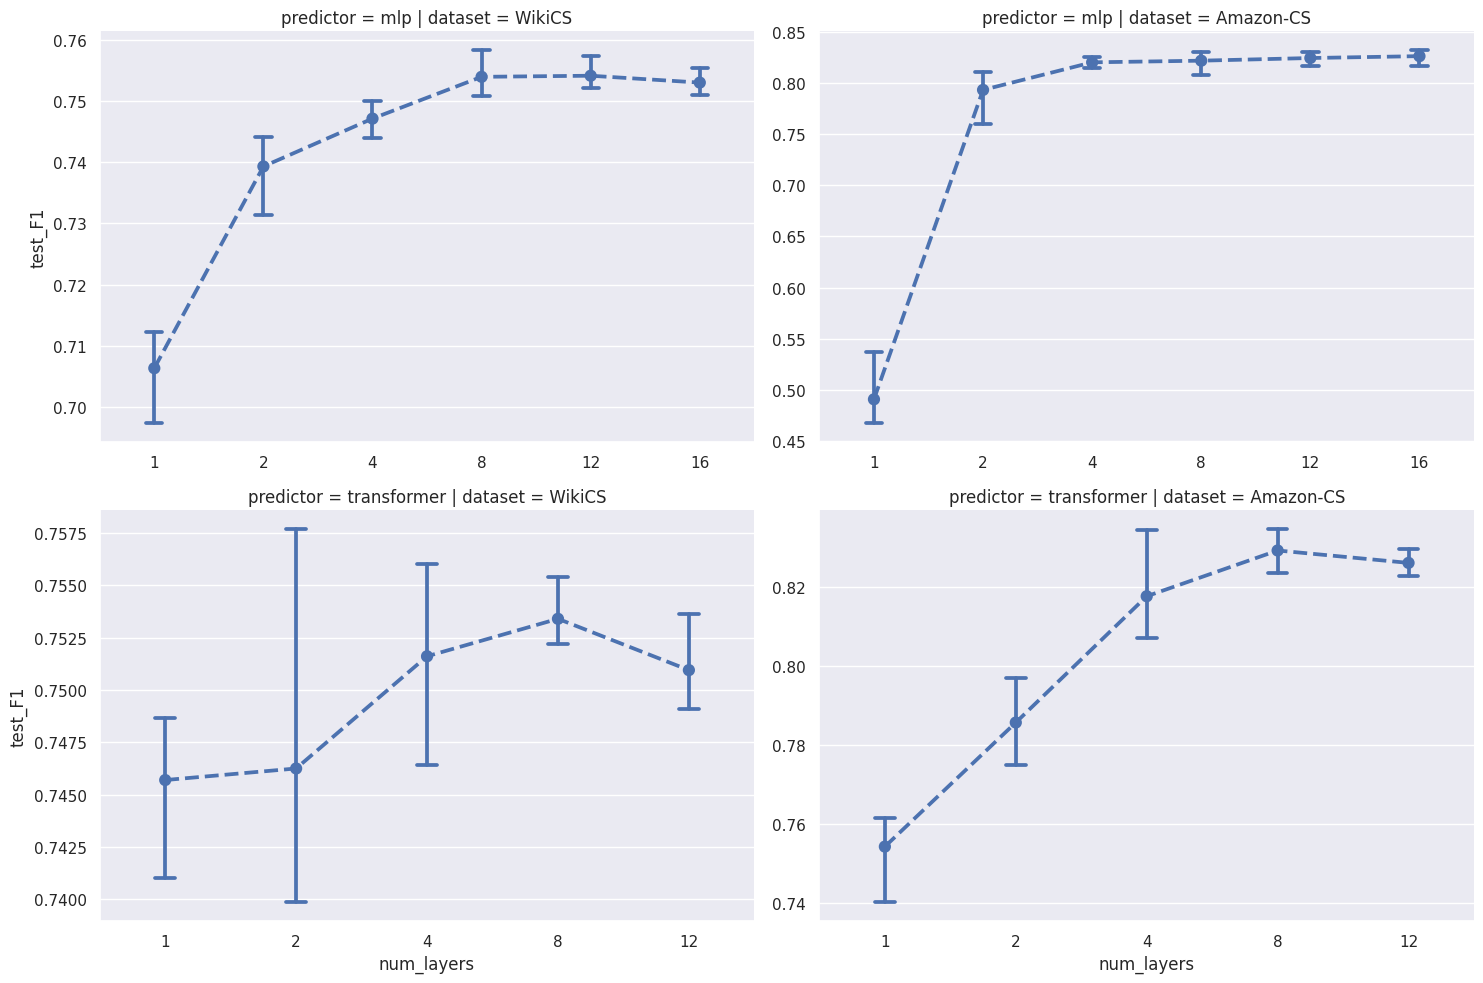

In [4]:
sns.catplot(
    data=res,
    x="num_layers",
    y="test_F1",
    col="dataset",
    row="predictor",
    kind="point",
    linestyles="--",
    capsize=0.15,
    aspect=1.5,
    sharey=False,
    sharex=False,
)

/home/jbinkowski/miniconda3/envs/gjepa/lib/python3.10/site-packages/seaborn/categorical.py:3201: UserWarning: Setting `sharex=False` with `color=None` may cause different levels of the `x` variable to share colors. This will change in a future version.
  warnings.warn(msg.format("sharex", "x"), UserWarning)


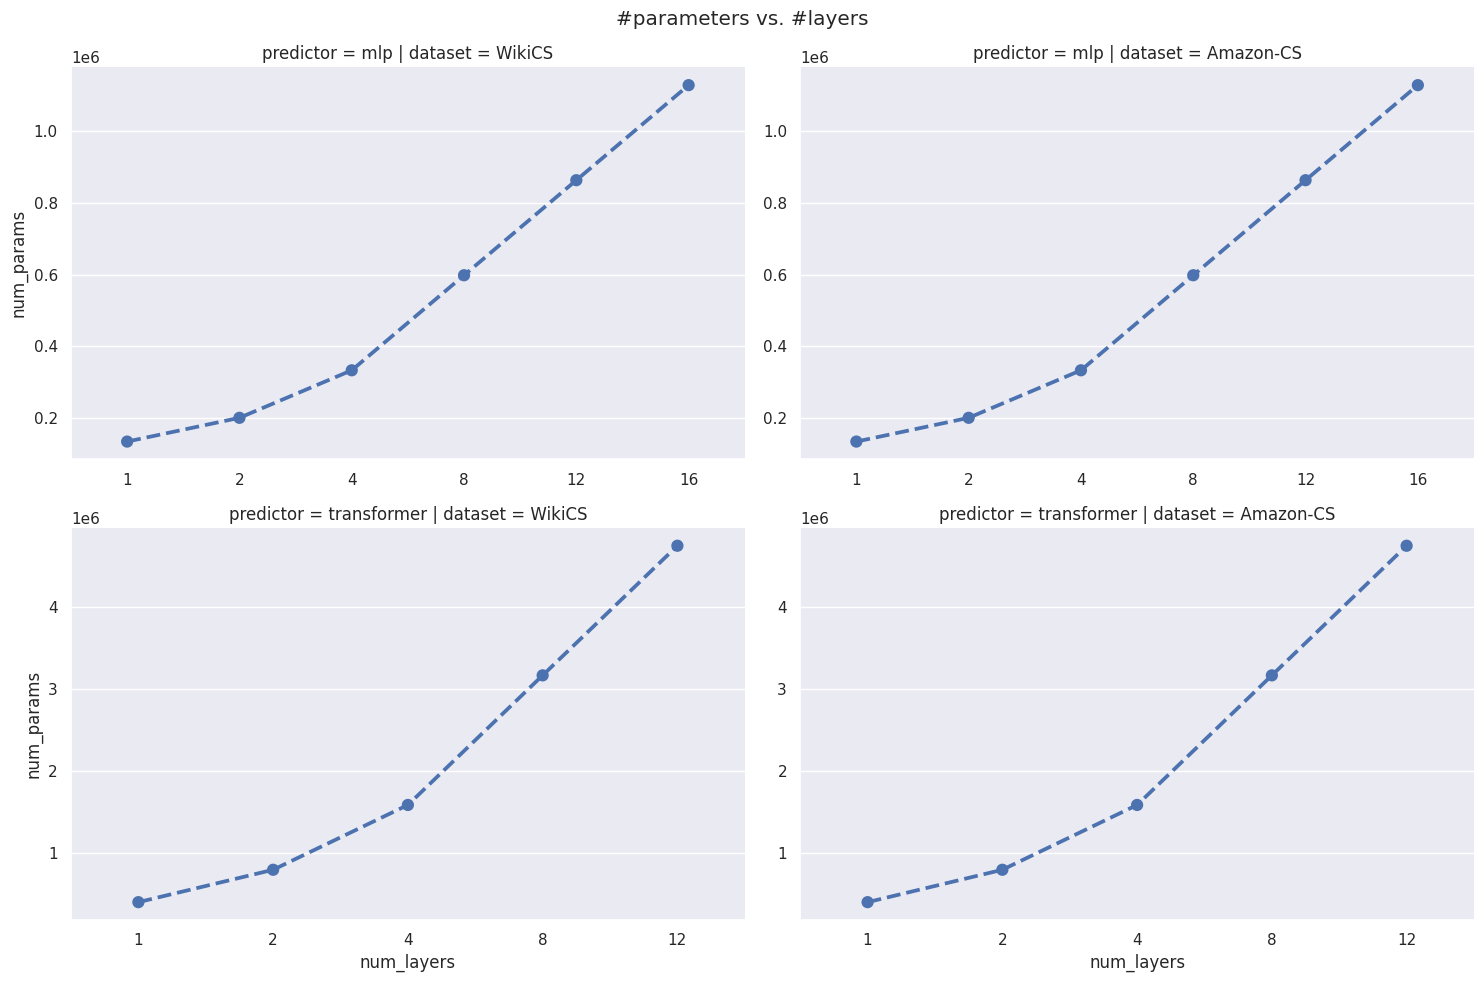

In [5]:
g = sns.catplot(
    data=res,
    x="num_layers",
    y="num_params",
    col="dataset",
    row="predictor",
    kind="point",
    linestyles="--",
    aspect=1.5,
    sharey=False,
    sharex=False,
)
g.fig.suptitle("#parameters vs. #layers")
g.fig.tight_layout()